Using device: cuda
Train size: 144174
Val size: 23741

Loading EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s] 



========== Epoch 1/10 ==========


Epoch 1: 100%|██████████| 2253/2253 [26:34<00:00,  1.41it/s, loss=0.489]


Train Loss: 0.4923 | Val Loss: 0.4694
✅ Best model saved

========== Epoch 2/10 ==========


...

Train Loss: 0.1289 | Val Loss: 0.2186

========== Epoch 10/10 ==========


Epoch 10: 100%|██████████| 2253/2253 [19:35<00:00,  1.92it/s, loss=0.148]


Train Loss: 0.1255 | Val Loss: 0.2243

Training Complete

Evaluating...


100%|██████████| 371/371 [03:29<00:00,  1.77it/s]



========== FINAL RESULTS ==========
Precision: 0.8786625486773197
Recall: 0.8517168666857574
Micro F1: 0.8649799069373942
Macro F1: 0.8531180011342652


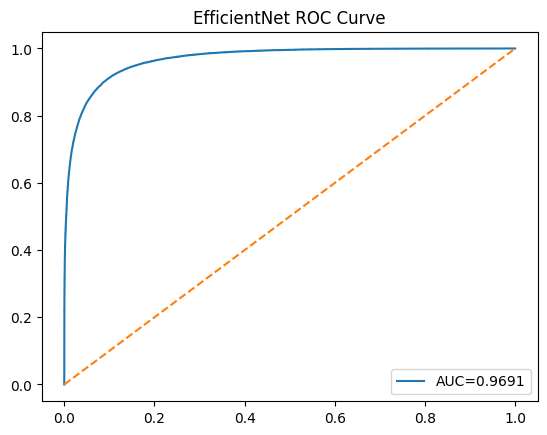

In [1]:
# ============================================================
# EFFICIENTNET-B0 TRANSFER (FAST VERSION - 10 EPOCHS)
# ============================================================

import os, json, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= PATHS =================
BASE_PATH = "/kaggle/input/datasets/iharshsinha/deepfashion2-top5-processed/processed"

TRAIN_IMG = os.path.join(BASE_PATH, "train/images")
TRAIN_ANN = os.path.join(BASE_PATH, "train/annos")

VAL_IMG   = os.path.join(BASE_PATH, "validation/images")
VAL_ANN   = os.path.join(BASE_PATH, "validation/annos")

# ================= LABEL MAP =================
LABEL_MAP = {
    "short sleeve top": 0,
    "long sleeve top": 1,
    "shorts": 2,
    "trousers": 3,
    "skirt": 4
}
NUM_CLASSES = 5

# ================= DATASET =================
class DeepFashionDataset(Dataset):

    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(ann_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]
        json_path = os.path.join(self.ann_dir, file)
        img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            return torch.zeros((3,224,224)), torch.zeros(NUM_CLASSES)

        if self.transform:
            image = self.transform(image)

        with open(json_path) as f:
            data = json.load(f)

        target = torch.zeros(NUM_CLASSES)

        for key, val in data.items():
            if key.startswith("item"):
                cat = val["category_name"]
                if cat in LABEL_MAP:
                    target[LABEL_MAP[cat]] = 1.0

        return image, target

# ================= TRANSFORMS =================
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ================= DATA =================
train_dataset = DeepFashionDataset(TRAIN_IMG, TRAIN_ANN, train_tf)
val_dataset   = DeepFashionDataset(VAL_IMG, VAL_ANN, val_tf)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

# ================= MODEL =================
print("\nLoading EfficientNet-B0...")

model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

# ================= LOSS =================
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# ================= TRAIN =================
epochs = 10
best_val_loss = float("inf")

for epoch in range(epochs):

    print(f"\n========== Epoch {epoch+1}/{epochs} ==========")

    # 🔥 PHASE 2: FULL FINE-TUNING
    if epoch == 3:
        print("\n🔥 Unfreezing FULL model")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # 🔥 PHASE 3: LR REDUCTION
    if epoch == 7:
        print("\n⚡ Reducing LR for final tuning")
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for images, labels in train_bar:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # SAVE BEST
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/effnet_best.pth")
        print("✅ Best model saved")

# Save final
torch.save(model.state_dict(), "/kaggle/working/effnet_last.pth")

print("\nTraining Complete")

# ================= EVALUATION =================
print("\nEvaluating...")

model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader):

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

precision = precision_score(all_labels, all_preds, average='micro')
recall = recall_score(all_labels, all_preds, average='micro')
micro_f1 = f1_score(all_labels, all_preds, average='micro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n========== FINAL RESULTS ==========")
print("Precision:", precision)
print("Recall:", recall)
print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

# ROC
fpr, tpr, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("EfficientNet ROC Curve")

plt.savefig("/kaggle/working/effnet_roc.png")
plt.show()